In [2]:
import os

os.chdir("..")
print(os.getcwd())

import sys
from pathlib import Path
from importlib import reload

/home/bbd0953/diffusion/src


# Model Evaluation Pipeline

## Single Model Eval. (Unlabeled)

*Step 1: Sample*  
    Generate Samples by running sample_batch_st.py in terminal

*Step 2: Examples, Metrics & Distributions*  
Plot examples, calculate Metrics & Distributions, Plot with LOFAR stats  
(This will take a few minutes, run step 3 in the meantime)

INFO (data.datasets): Loading images...
INFO (data.datasets): No names loaded from hdf5 file.
INFO (data.datasets): Data set initialized.


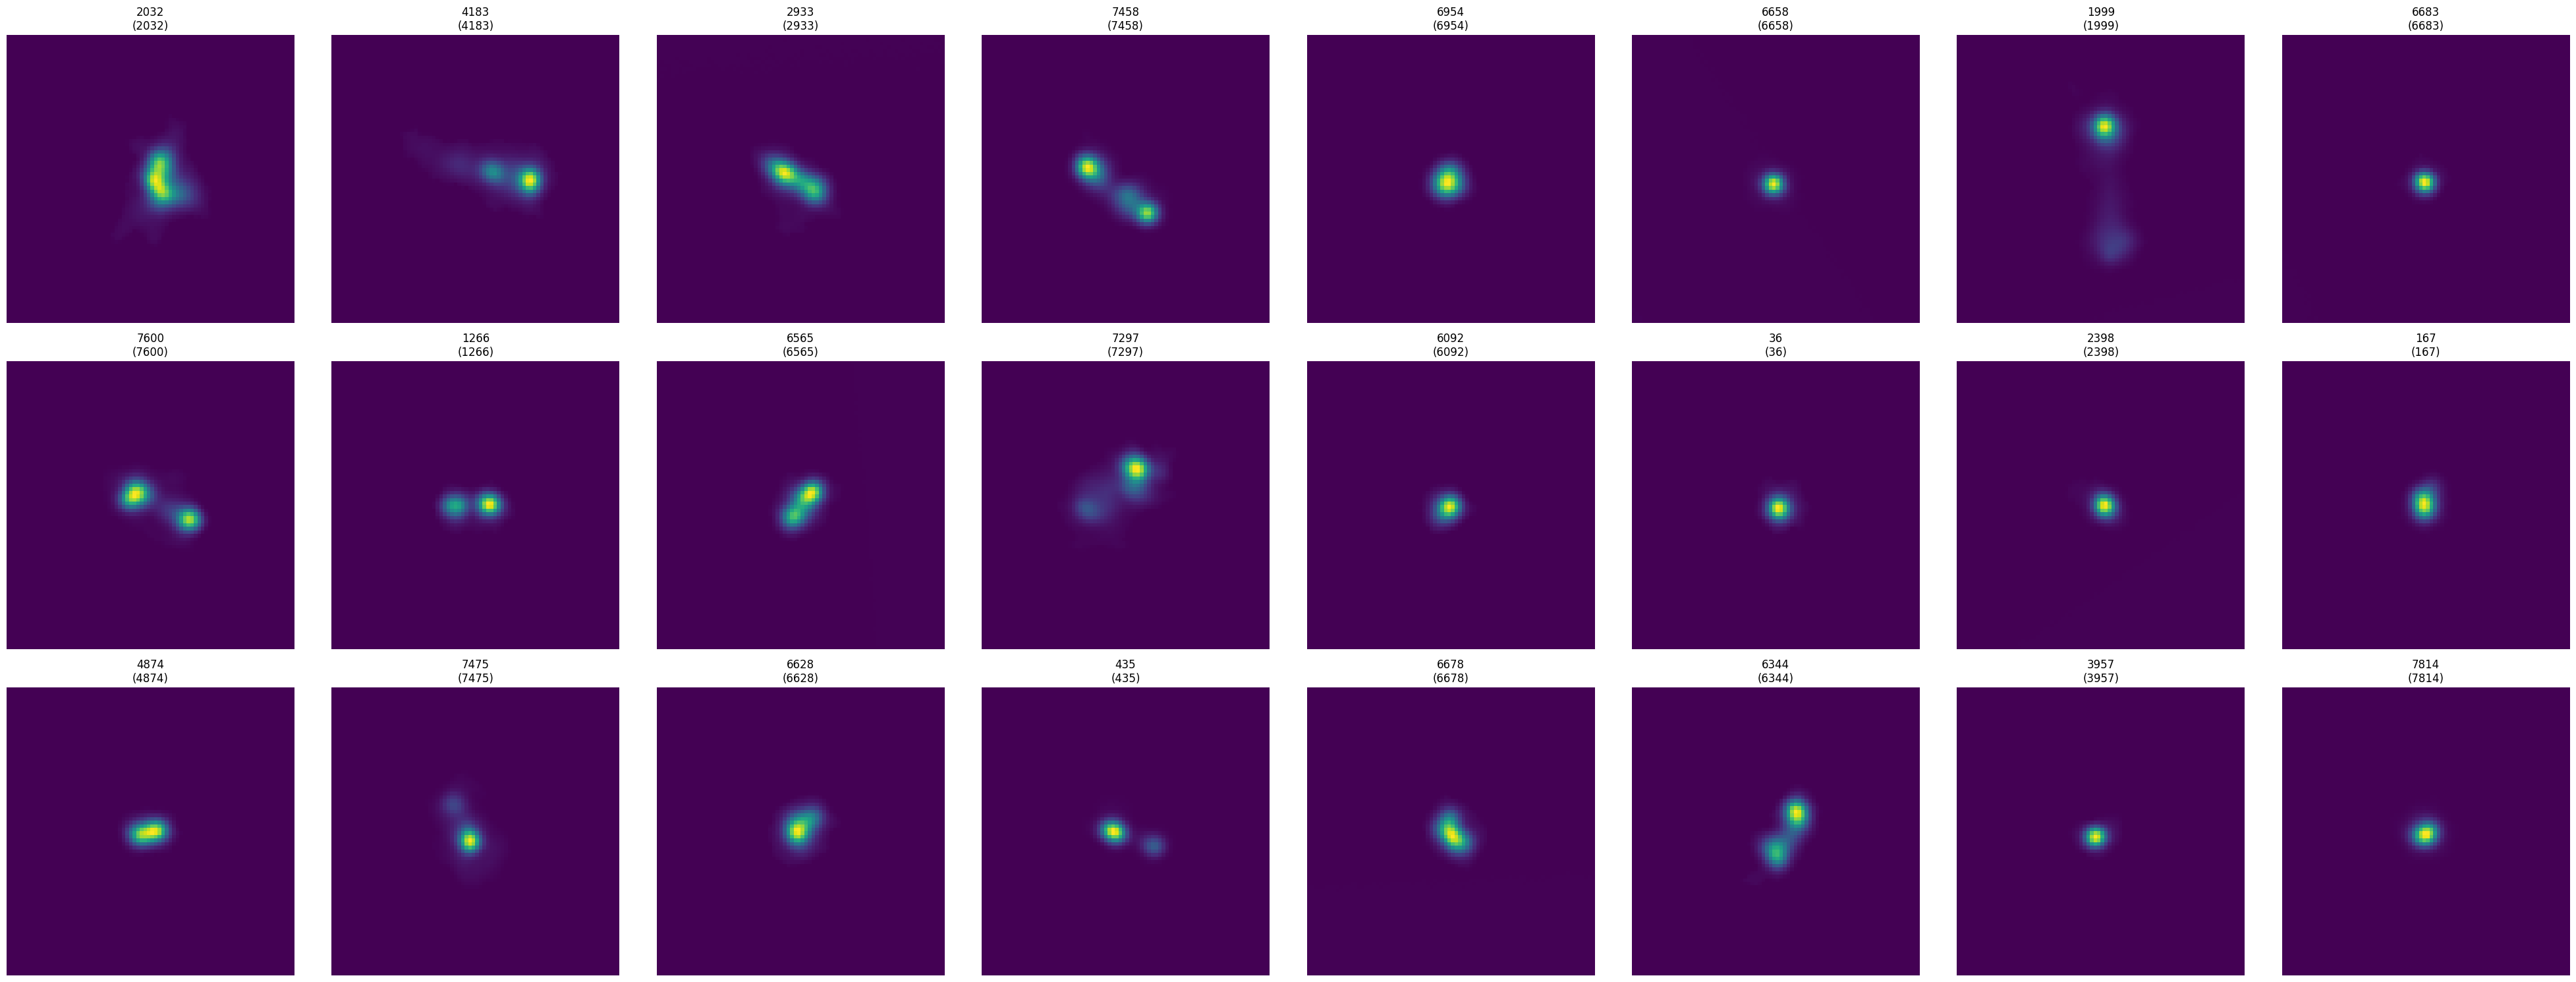

In [3]:
from importlib import reload
import analysis.model_evaluation as meval
reload(meval)
import plotting.image_plots

reload(plotting.image_plots)
from plotting.image_plots import plot_image_grid_from_file
import utils.paths as paths

import data.datasets
reload(data.datasets)
from data.datasets import SamplesDataset

dset = SamplesDataset('Prototypes_Model')

fig_grid, _ = dset.plot_image_grid(n_rows=3, n_cols=8)
fig_grid.show()

In [ ]:
from pathlib import Path
from utils.paths import LOFAR_SUBSETS
import analysis.model_evaluation as meval
import analysis.image_metrics as imet

reload(imet)
reload(meval)

distributions = meval.get_distributions(file, force=True)
figs = meval.get_metrics_plots(
    file,
    labels=["Model (QKV Corrected)"],
    train_path=LOFAR_SUBSETS["0-clip"],
    train_label="120'' SNR5 0-Clipped",
    save=False,
)

*Step 3: PyBDSF Run*  
Run bdsf_analysis.py on fs08, with the generated samples and if not done yet with training data.

*Step 3: PyBDSF Evaluation*  
Compare the results of PyBDSF analysis

In [ ]:
from utils.paths import LOFAR_SUBSETS
import analysis.bdsf_evaluation as bdsfeval

reload(bdsfeval)
from analysis.bdsf_evaluation import get_bdsf_metrics_plots

d = bdsfeval.get_bdsf_distributions(file, force=True)

fig, ax = get_bdsf_metrics_plots(
    file,
    labels=["QKV-Corr."],
    train_path=LOFAR_SUBSETS["0-clip"],
    train_label="120'' SNR5 0-Clipped",
)

## Paper Plots

In [ ]:
import plotting.paper_plots as pplt
from matplotlib import colormaps as cm

reload(pplt)

pplt.paper_plots_bdsf(file)

In [ ]:
import plotting.paper_plots as pplt
reload(pplt)
pplt.paper_plots_pxstats(file)

## Metric Peek (Sampling w. Context)

In [ ]:
import torch
import numpy as np
import analysis.bdsf_evaluation as bdsfeval

reload(bdsfeval)

samples = torch.load(file, map_location="cpu")[:, -1].squeeze()
# context = np.load('/home/bbd0953/diffusion/analysis_results/Fmax_Context_Dropout/Fmax_Context_Dropout_context_10000_guidance_strength=1.00e-01.npy')

metrics = bdsfeval.get_metric_dict(file.parent, force=True)

In [ ]:
# Sort all elements in metrics by metrics['Image_id']
import numpy as np

sort_idxs = np.argsort(metrics["Image_id"].astype(int))
for key, value in metrics.items():
    metrics[key] = value[sort_idxs]

In [ ]:
metrics["Image_id"].astype(int)

In [ ]:
for key, arr in metrics.items():
    print(key, len(arr))

In [ ]:
import plotting.plot_utils

reload(plotting.plot_utils)
from plotting.plot_images import metric_peek


metric_peek(
    metrics[m := "q0.9_area"],
    np.linspace(0, 2000, 11),
    # metrics['model_gaus_arr'],
    samples,
    metric_name=m,
)

## Compare between Models (Unlabeled)

Image Metrics:

In [ ]:
import utils.paths as paths
import analysis.model_evaluation as meval

model_name = "Data_Augmented"

files = [
    paths.ANALYSIS_PARENT / "Data_Augmented/Data_Augmented_samples_10000_guidance_strength=1.00e-01.pt",
    '/hs/fs08/data/group-brueggen/tmartinez/diffusion/analysis_results/LOFAR_QKV-Corr/LOFAR_QKV-Corr_samples_10000_guidance_strength=1.00e-01.pt',
]

files = [Path(f) for f in files]

# distributions = [meval.get_distributions(f) for f in files]
labels = [
    "Original",
    "QKV-Corr.",
]


figs = meval.get_metrics_plots(
    files,
    labels=labels,
    cmap="winter",
    train_path=paths.LOFAR_SUBSETS["0-clip"],
)

BDSF Metrics:

In [ ]:
import analysis.bdsf_evaluation as bdsfeval

reload(bdsfeval)

fig, ax = bdsfeval.get_bdsf_metrics_plots(
    files,
    labels=labels,
    train_path=paths.LOFAR_SUBSETS["0-clip"],
    cmap="winter",
    bdsf_dir=["bdsf_10000", "bdsf"],
)

Loss vs Noise Level:

In [ ]:
import numpy as np
from importlib import reload
import plotting.plot_utils

reload(plotting.plot_utils)
from scripts.loss_vs_noise_level import plot_loss_over_noise_levels

files = [
    ANALYSIS_PARENT / f
    for f in [
        # '/home/bbd0953/diffusion/analysis_results/EDM_valFix/noise_level_losses.npz',
        "EDM_Pmean=-2.5_Pstd=1.8/noise_level_losses.npz",
        "EDM_Pmean=-0.8_Pstd=2.2/noise_level_losses.npz",
    ]
]

file_dicts = [np.load(f) for f in files]
plot_loss_over_noise_levels(
    file_dicts, labels=labels[1:], best_only=True, P_mean=[-2.5, -0.8], P_std=[1.8, 2.2]
)

## Class-Conditioned Model Eval 

_Step 1: Sample_  
Generate samples with model.samples

_Step 2: Distributions_  
Calculate distributions for each class label separately.

In [ ]:
from importlib import reload
import analysis.model_evaluation as meval
from plotting.plot_images import plot_image_grid
from datasets.firstgalaxydata import label_to_class_dict
import utils.data_utils as du

reload(du)
from utils.data_utils import EvaluationDataset
from torch.utils.data import DataLoader
import numpy as np

file = Path(
    "/hs/babbage/data/group-brueggen/tmartinez/diffusion/analysis_results/FIRST_Labeled/FIRST_Labeled_samples_8000_guidance_strength=7.50e-01.pt"
)
images = EvaluationDataset(file)

lbl2cls = label_to_class_dict()

for i in range(4):
    # Assuming equal number of samples for each class
    n = int(len(images) / 4)
    idxs = np.random.choice(range(n * i, n * (i + 1)), 64, replace=False)
    plot_image_grid(
        [images[i] for i in idxs],
        suptitle=lbl2cls[i],
        # titles=idxs,
    )

In [ ]:
from importlib import reload
import analysis.model_evaluation as meval
from plotting.plot_images import plot_image_grid
from datasets.firstgalaxydata import label_to_class_dict
import utils.data_utils as du

reload(du)
from utils.data_utils import EvaluationDataset
from torch.utils.data import DataLoader
import numpy as np

file = Path(
    "/hs/babbage/data/group-brueggen/tmartinez/diffusion/analysis_results/FIRST_Labeled/FIRST_Labeled_samples_8000_guidance_strength=1.00e-01.pt"
)
images = EvaluationDataset(file)

lbl2cls = label_to_class_dict()

for i in range(4):
    # Assuming equal number of samples for each class
    n = int(len(images) / 4)
    idxs = np.random.choice(range(n * i, n * (i + 1)), 64, replace=False)
    plot_image_grid(
        [images[i] for i in idxs],
        suptitle=lbl2cls[i],
        # titles=idxs,
    )

In [ ]:
from torchvision.transforms import CenterCrop
from torch.utils.data import DataLoader
import numpy as np
from plotting.plot_images import plot_image_grid
from datasets.firstgalaxydata import label_to_class_dict
import matplotlib.pyplot as plt

lbl2cls = label_to_class_dict()

n_images = 4
for i in [3]:
    # Assuming equal number of samples for each class
    n = int(len(images) / 4)
    idxs = np.random.choice(range(n * i, n * (i + 1)), 4, replace=False)

    plot_image_grid([images[i][0] for i in idxs], suptitle=None, vmin=0, n_rows=1)

### Quick Sampling

In [ ]:
import numpy as np
from utils.init_utils import load_model_by_name
from utils.device_utils import distribute_model
from models.sample import sample_batch

# Load model
model_name = "FIRST_Labeled"
model = load_model_by_name(model_name, key="model")
model, dev = distribute_model(model)

In [ ]:
# Set up labels
n_samples = 49
label = 3
labels = np.ones(n_samples) * label

# Sample
batch = sample_batch(
    model,
    bsize=n_samples,
    label_batch=torch.Tensor(labels),
    return_steps=False,
    guidance_strength=0.1,
)

In [ ]:
from plotting.plot_images import plot_image_grid

plot_image_grid(batch, vmin=-1)

## Compare Snapshots

Step 1: Sample from snapshots by running sample_snapshot_loop() from sample_batch_st.py in terminal.  
Samples are saved under: _ANALYSIS_PARENT/[model name]/snapshot_samples_

Step 2: Calculate stats and distributions for all snapshot samples.

In [ ]:
from utils.paths import ANALYSIS_PARENT, LOFAR_SUBSETS
import analysis.model_evaluations as meval

reload(meval)

model_name = "EDM_SNR5_120as"  # Add model name here
train_path = LOFAR_SUBSETS["120asLimit_SNR>=5"]  # Add training data path here

# Optional, else set to None:
final_samples_file = "/home/bbd0953/diffusion/analysis_results/EDM_SNR5_120as/EDM_SNR5_120as_samples_10000Imgs_T=25.pt"

samples_files = sorted(
    (ANALYSIS_PARENT / model_name / "snapshot_samples").glob(
        f"{model_name}_samples*.pt"
    )
)

for f in samples_files:
    print(f"Working on {f.name}...")
    distributions = meval.get_distributions(f)

labels = [s for f in samples_files for s in f.name.split("_") if "it=" in s]


if final_samples_file is not None:
    samples_files.append(Path(final_samples_file))
    labels.append("Final")

n_min, n_max = 2, None

figs = meval.get_metrics_plots(
    samples_files[n_min:n_max],
    labels=labels[n_min:n_max],
    cmap="copper",
    train_path=train_path,
)

In [ ]:
from pathlib import Path

samples_files = [
    Path(p)
    for p in [
        "/path/something_blabla_it=1000.pt",
        "/path/something_blabla_it=10000.pt",
        "/path/something_blabla_it=100000.pt",
    ]
]

labels = [s for n in samples_files for s in n.name.split("_") if "it=" in s]

labels

## Loss vs. Noise Level

*Compute Loss vs. Noise*  
Calculate loss vs. noise level by running loss_vs_noise_level.py

*Plot Loss vs Noise*  
Plot loss vs. noise level

In [ ]:
import numpy as np
from importlib import reload
import plotting.plot_utils

reload(plotting.plot_utils)
from scripts.loss_vs_noise_level import plot_loss_over_noise_levels

file = Path(
    "/home/bbd0953/diffusion/analysis_results/Unclipped_H5/noise_level_losses.npz"
)

file_dict = np.load(file)
plot_loss_over_noise_levels(
    file_dict,
    labels="Unclipped_ImgNorm",
    P_mean=[-2.5],
    P_std=[1.8],
    savefig=file.parent / f"{file.parent.name}_{file.stem}.png",
)

# Train Data

## FIRST Dataset

Load Dataset:

In [ ]:
from utils.data_utils import TrainDatasetFIRST

dset = TrainDatasetFIRST()

In [ ]:
import numpy as np

# Choose 3 random examples for each of the 4 class labels in dset
n = 3
idxs = np.array(
    [
        np.random.choice(np.argwhere(dset.labels == i)[0], n, replace=False)
        for i in range(1)
    ]
).T.flatten()

from plotting.plot_images import plot_image_grid

title = lambda l: dset.class_dict[l]
plot_image_grid(
    [dset[i][0] for i in idxs],
    titles=[title(l.item()) for l in dset.labels[idxs]],
    n_rows=3,
)

### Plot Image Grids

In [ ]:
from torchvision.transforms import CenterCrop
from torch.utils.data import DataLoader
import numpy as np
from plotting.plot_images import plot_image_grid
from datasets.firstgalaxydata import label_to_class_dict
import matplotlib.pyplot as plt

lbl2cls = label_to_class_dict()

n_images = 4
for lbl, cl in lbl2cls.items():
    mask = dset.labels == lbl
    idxs = np.random.choice(np.arange(len(dset))[mask], n_images, replace=False)

    plot_image_grid([dset[i][0] for i in idxs], suptitle=None, vmin=-1, n_rows=1)

In [ ]:
images[0].shape

In [ ]:
plt.hist(images[0])
plt.show()

In [ ]:
from torch.utils.data import DataLoader
from plotting.plot_images import plot_image_grid
import matplotlib.pyplot as plt

n_rows = n_cols = 10

# Pick a random sample from the dataset
dataloader = DataLoader(dataset, batch_size=n_rows * n_cols, shuffle=False)
for batch in dataloader:
    plot_image_grid(batch[0], n_rows=n_rows, n_cols=n_cols, vmin=0, vmax=1)
    plt.show()

In [ ]:
test_img = dataset[0][0]
test_img

### Plot Distributions

In [ ]:
from analysis import image_metrics as imet
import analysis.model_evaluations as meval

reload(imet)
reload(meval)

# Calculate image metrics
img_metrics = meval.metrics_dict_from_data(dataset, n_bins=4)
distr = meval.distributions_from_metrics(img_metrics)

In [ ]:
import plotting.plot_metrics as putil

putil.metrics_plots(distr, labels="FIRST")

In [ ]:
FIRST_distr = meval.distributions_from_metrics(FIRST_metrics)

In [ ]:
import plotting.plot_utils

reload(plotting.plot_utils)
from plotting.plot_metrics import metrics_plots

plots = metrics_plots(FIRST_distr, labels="FIRST", colors="darkorange")

In [ ]:
# Calculate distributions separately for every class
dataset.selected_classes
classes = ["FRI", "FRII", "Compact", "Bent"]

distributions = []
for cls in classes:
    print(f"\n\nCalculating metrics for class {cls}...")
    cls_dset = FIRSTGalaxyData(
        selected_split=["test", "train", "valid"],
        selected_classes=[cls],
        transform=eval_transform(80),
    )
    cls_metrics = meval.metrics_dict_from_data(cls_dset)
    cls_distr = meval.distributions_from_metrics(cls_metrics)
    distributions.append(cls_distr)

In [ ]:
import plotting.plot_utils

reload(plotting.plot_utils)
from plotting.plot_metrics import metrics_plots

plots = metrics_plots(distributions, labels=classes, cmap="tab10")

In [ ]:
from utils.paths import ANALYSIS_PARENT

out_folder = ANALYSIS_PARENT / "FIRST"
out_folder.mkdir(exist_ok=True)

In [ ]:
# Save plots
names = ["FIRST_pixel_metrics_plot", "FIRST_shape_metrics_plot"]

for plot, name in zip(plots, names):
    plot[0].savefig(out_folder / f"{name}.pdf")

In [ ]:
# Save distributions
import numpy as np

for cls, distr in zip(classes, distributions):
    np.save(out_folder / f"FIRST_{cls}_metrics.npy", distr)

### Look at H5 files

In [ ]:
import h5py
import numpy as np

file = "/home/bbd0953/diffusion/image_data/FIRST/galaxy_data_h5.h5"

with h5py.File(file, "r") as f:
    print([i for i in f.attrs.items()])
    for k, v in f["data_0"]["Img"].attrs.items():
        print(f"{k}: {v}")

### Make Catalog

In [ ]:
import h5py
import numpy as np
from tqdm import tqdm
import pandas as pd
from pathlib import Path

file = Path("/home/bbd0953/diffusion/image_data/FIRST/galaxy_data_h5.h5")

keys_data = ["Label_CDL1", "Label_literature"]
keys_img = [
    "RA",
    "DEC",
]

catalog_dict = {key: [] for key in ["Source_Name", "FGD_Key"] + keys_data + keys_img}

with h5py.File(file, "r") as f:
    for key, entry in tqdm(f.items()):
        # Source identifiers
        catalog_dict["FGD_Key"].append(key)
        catalog_dict["Source_Name"].append(
            entry["Img"].attrs["coord_str"].replace(".png", "")
        )

        # Labels
        for k in keys_data:
            catalog_dict[k].append(entry[k][()].astype(np.uint8))

        # Coords
        for k in keys_img:
            catalog_dict[k].append(entry["Img"].attrs[k])

catalog_df = pd.DataFrame(catalog_dict)
catalog_df.to_csv(file.parent / f"catalog_{file.stem}.csv", index=False)

## Distributions of Train Data Subsets

In [ ]:
import analysis.model_evaluations as meval
import utils.paths as paths
import plotting.plot_utils as plot_utils

### 0-Clipped, SNR>=5, 120as Limit:

In [ ]:
import utils.data_utils
reload(utils.data_utils)
from utils.data_utils import plotting.plot_imagesTrainDataset
import numpy as np

dataset = TrainDataset(paths.LOFAR_SUBSETS['0-clip_unscaled'])

n = 10
idxs = np.random.choice(len(dataset), n**2, replace=False)
plot_utils.plot_image_grid([dataset[i] for i in idxs], n_rows=n, vmin=-1, );

In [ ]:
dataset[0].shape

### Unclipped, SNR>=5, 120as Limit:

In [ ]:
from utils.data_utils import EvaluationDataset
import numpy as np

dataset = Eplotting.plot_imagesths.LOFAR_SUBSETS['120asLimit_SNR>=5'])

n = 8
idxs = np.random.choice(len(dataset), n**2, replace=False)
plot_utils.plot_image_grid(dataset.data[idxs], n_rows=n, vmin=0, )

### Unclipped, SNR>=5, 50as Limit:

In [ ]:
reload(paths)

figs = meval.get_metrics_plots(
    [],
    train_path=paths.LOFAR_SUBSETS["unclipped_SNR>=5_50asLimit"],
    train_label="Unclipped - SNR>=5 - 50as Limit",
)

### Unclipped, SNR>=3:

In [ ]:
reload(paths)

figs = meval.get_metrics_plots(
    [],
    train_path=paths.LOFAR_SUBSETS["unclipped_SNR>=5"],
    train_label="SNR>=5",
)

### 1 Sigma Clipped:

In [ ]:
figs = meval.get_metrics_plots(
    [],
    train_path=paths.LOFAR_SUBSETS["1sigma-clipped"],
    train_label="1sigma-clipped",
)

In [ ]:
import h5py
import numpy as np

with h5py.File(paths.LOFAR_SUBSETS["1sigma-clipped"], "r") as f:
    images = np.array(f["images"])

In [ ]:
from plotting import plot_images as putil

n = 10

# Pick n**2 random images
idxs = np.random.choice(len(images), n**2, replace=False)
images = images[idxs]

putil.plot_image_grid(images, vmin=0)

### Unclipped, Image-minmax:

In [ ]:
from utils.paths import LOFAR_SUBSETS
from importlib import reload
import analysis.image_metrics as imet
import analysis.model_evaluations as meval

reload(imet)
reload(meval)

path = LOFAR_SUBSETS["unclipped_H5"]

# metrics = meval.metrics_dict_from_data(path, n_bins=1)

meval.get_metrics_plots(
    [],
    train_path=path,
    force_train=True,
)

In [ ]:
from utils.data_utils import EvaluationDataset

dset = EvaluationDataset(path)

In [ ]:
from plotting.plot_images import plot_image_grid
import numpy as np

n = 5

# Pick n**2 random images
idxs = np.random.choice(len(dset), n**2, replace=False)

plot_image_grid(dset.data[idxs], vmin=0)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

angles = metrics['WPCA_Angle']
elongations = metrics['WPCA_Elongation']

# 2d historgram, normalized over elongation axis
counts, ex, ey = np.histogram2d(angles, elongations, bins=100)
counts = counts.T
counts /= counts.sum(axis=1)

def centers(edges):
    return (edges[:-1] + edges[1:]) / 2

print(counts.shape)

fig, ax = plt.subplots(dpi=150, subplot_kw={"projection": "3d"})

# Plot the surface
x, y = np.meshgrid(centers(ex), centers(ey))
c = ax.plot_surface(
    x, y, counts
)
ax.set_xlabel('Angle')
ax.set_ylabel('Elongation')
ax.set_zscale('log')

%matplotlib widget

plt.show()

In [ ]:
min(angles)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

angles = metrics["WPCA_Angle"]
elongations = metrics["WPCA_Elongation"]

# 2d historgram, normalized over elongation axis
counts, ex, ey = np.histogram2d(
    angles, elongations, bins=(np.linspace(0, 180, 101), np.linspace(0, 1, 101))
)
counts = counts.T
counts /= counts.sum(axis=1)

print(counts.shape)

fig, ax = plt.subplots(dpi=150)

im = ax.imshow(
    counts,
    extent=(ex[0], ex[-1], ey[0], ey[-1]),
    norm=mpl.colors.LogNorm(),
    aspect="auto",
    origin="lower",
)
fig.colorbar(im, ax=ax, label="Counts")
ax.set_xlabel("WPCA Orientation Angle (deg)")
ax.set_ylabel("WPCA Elongation")
plt.show()

### Zero-clipped Subset:

In [ ]:
import plotting.plot_metrics


distr_dict = meval.get_distributions(
    plot_function(distr_dict, color='darkorange', label='LOFAR')
    for plot_function in [plotting.plot_metrics.pixel_metrics_plot, plotting.plot_metrics.shape_metrics_plot]
]

pixel[0].show()
shape[0].show()

### Unclipped, absolute value, subset-scaled:

In [ ]:
import h5py
import numpy as np

p = Path(
    "/home/bbd0953/diffusion/image_data/LOFAR/lofar_zoom_unclipped_subset_80p_abs_subset-norm.hdf5"
)

In [ ]:
import analysis.model_evaluations as meval

meval.get_metrics_plots(p, labels=["80p_uncl_abs_subset-norm"], force=False)

### Zero-clipped, absolute value, normalized over dataset, then create subset:

Load images from subset file

In [ ]:
import h5py
import numpy as np

p = Path(
    "/home/bbd0953/diffusion/image_data/LOFAR/lofar_zoom_unclipped_subset_80p_abs_dset-norm.hdf5"
)

with h5py.File(p, "r") as f:
    # Print all keys
    images = np.array(f["images"])
    names = np.array(f["names"].asstr())

Look at pixel distribution

In [ ]:
import matplotlib.pyplot as plt

plt.hist(images.flatten(), bins=256)
plt.yscale("log")

Load processed cutouts pre-norm

In [ ]:
p_cut = Path(
    "/home/bbd0953/diffusion/image_data/LOFAR/cutouts/cutouts-1p5las-TrueoptCoords_processed_abs_dset-norm.hdf5"
)

with h5py.File(p_cut, "r") as f:
    images_cut = np.array(f["images_clipped"])
    names_cut = np.array(f["images_clipped_names"].asstr())

    images_resized = np.array(f["images_resized"])
    names_resized = np.array(f["images_resized_names"].asstr())

In [ ]:
# Create a dictionary from names_resized where the keys are the names and the values are the indices
indices_dict = {name: i for i, name in enumerate(names_resized)}

# Find the set difference
set_diff = set(names_resized) - set(names)

# Use the dictionary to index into images_resized
images_diff = [images_resized[indices_dict[name]] for name in set_diff]
images_subset = [images_resized[indices_dict[name]] for name in names]

In [ ]:
len(images_diff), len(images_subset)

In [ ]:
import matplotlib.pyplot as plt
from utils.stats_utils import norm

c_cut, b_cut = np.histogram(np.abs(images_resized).flatten(), bins=128)
c_diff, _ = np.histogram(np.abs(images_diff).flatten(), bins=b_cut)
c_sub, _ = np.histogram(np.abs(images_subset).flatten(), bins=b_cut)

In [ ]:
fig, ax = plt.subplots()

labels = ["from cutouts", "removed (Peak_flux <= 0.75)", "filtered (Peak_flux > 0.75)"]

for c, label in zip([c_cut, c_diff, c_sub], labels):
    ax.stairs(norm(c), b_cut, fill=False, label=label, alpha=0.5)
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("Pixel Value")
ax.set_ylabel("Frequency (over dataset)")
fig.show()

Load catalog:


In [ ]:
import pandas as pd

CATALOG_FILE = "/home/bbd0953/RadioGalaxyImage/image_data/LOFAR/6-LoTSS_DR2-public-resolved_sources.csv"

catalog = pd.read_csv(CATALOG_FILE)

In [ ]:
# Print all column names in df
print(catalog.columns)

In [ ]:
catalog_cut = catalog[catalog["Source_Name"].isin(names_cut)]
catalog_resized = catalog[catalog["Source_Name"].isin(names_resized)]

In [ ]:
cut_means = np.array([np.abs(a).mean() for a in images_cut])

In [ ]:
plt.scatter(
    catalog_cut["Peak_flux"],
    [np.abs(a).mean() for a in images_cut],
    s=0.05,
    alpha=0.3,
    label="From cutouts (before resize)",
    c=catalog_cut["LAS"],
)
"""
plt.scatter(catalog_resized['Peak_flux'], np.abs(images_resized).mean(axis=(1, 2)),
            s=0.05, alpha=0.3, label='From cutouts (after resize)')
"""

# Vertical line at 0.75
plt.axvline(0.75, color="k", linestyle="--", alpha=0.5, label="Peak_flux = 0.75")

plt.xlabel("Peak Flux")
plt.ylabel("Mean Image Pixel Value")

plt.xscale("log")
plt.yscale("log")

plt.legend()

In [ ]:
plt.scatter(
    catalog_cut["Peak_flux"],
    catalog_cut["LAS"],
    s=0.05,
    alpha=0.3,
    label="From cutouts (before resize)",
)
"""
plt.scatter(catalog_resized['Peak_flux'], np.abs(images_resized).mean(axis=(1, 2)),
            s=0.05, alpha=0.3, label='From cutouts (after resize)')
"""

# Vertical line at 0.75
plt.axvline(0.75, color="k", linestyle="--", alpha=0.5, label="Peak_flux = 0.75")

plt.xlabel("Peak Flux")
plt.ylabel("LAS")

plt.xscale("log")
plt.yscale("log")

plt.legend()

In [ ]:
plt.hist(catalog["Peak_flux"], bins=128)
plt.yscale("log")

## Metric Peeks

In [ ]:
from utils import paths
from utils.data_utils import EvaluationDataset, TrainDataset

dataset = TrainDataset(paths.LOFAR_SUBSETS["0-clip_unscaled"])

In [ ]:
dataset.transform_max_vals()
mx_tr = dataset.max_values_tr
mx_tr.max(), mx_tr.min()

In [ ]:
import numpy as np

metric_peek(
    dataset.max_values_tr,
    np.linspace(-3, 3, 7),
    dataset.data.squeeze().numpy(),
    names=[
        f"{mx:.2e} ({mx_tr:.2f})"
        for mx, mx_tr in zip(dataset.max_values, dataset.max_values_tr)
    ],
    metric_name="F_tr",
)